# Credit Card Fraud Detection
# Detecting fraudulent transactions using Machine Learning
** Dataset:** 284,807 real credit card transactions(kaggle -ULB)

**Problem Statement:** Only 0.17% of transactions are fraud - this severe class imbalance means a model can achieve 99.8% accuracy by predicting
    everything as legitimate, while catching zero fraud cases.
    
**Goal:** Build a model that catches fraud without flagging too many legit transactions

**Tools:** Python, Pandas, Scikit-learn, Matplotlib

## Exploring the data to understand the class imbalance problem

In [13]:
import pandas as pd
import numpy as np

#load the dataset
df = pd.read_csv("C:\\Users\\Rishitha\\OneDrive\\Desktop\\Python for data analysis\\creditcard.csv")
#shape
print("shape:",df.shape)
print("\nColumn names:\n", df.columns.tolist()) #tolist() converts pandas index object into a plain python list - just to print it cleanly
#data types and nulls
print("\n info")
df.info()
print("\n Missing values")
print(df.isnull().sum().sum(), "total missing values")
#first 5 rows
print("\n first 5 rows")
df.head()
#summary statistics
print("\n Amount & Class")
print(df[['Amount','Class']].describe())
      #the most impportant line for fraud detections
print("\n class distribution")
print(df['Class'].value_counts())
print("\n Fraud percentage:{:.4f}%".format(
      df['Class'].sum()/len(df)*100
     ))
#Counts how many times each unique value appears in that column-- value counts
#eda starter template.
#load → shape → columns → dtypes → nulls → head → describe → target distribution -- every ds project starts with these steps

shape: (284807, 31)

Column names:
 ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

 info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non

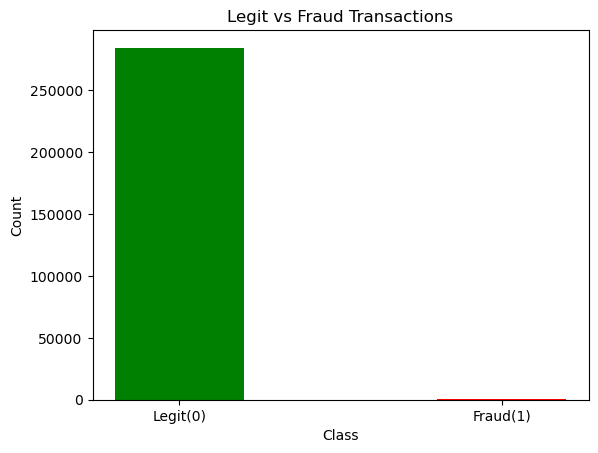

In [19]:
import matplotlib.pyplot as plt
class_counts = df['Class'].value_counts()
#what a bar chart needs - x axis - categories o and 1, y axis - counts, a title and label on each axis
plt.bar(class_counts.index, class_counts.values, width =0.4,color =['Green','red'])
plt.xticks([0,1],['Legit(0)','Fraud(1)']) #ticks control what labels to appear on the x axis, it takes 2 things, where to place 0 and 1 positions,and what to write at these position
plt.title("Legit vs Fraud Transactions") #title
plt.xlabel("Class") #x axis label
plt.ylabel("Count") #y axis label
plt.show()  #show the chart #my first data visualizations

## Exploratory Data Analysis — Understanding Fraud Patterns
Before building any model, let's understand what fraud actually looks like in this dataset.

In [16]:
# Fraud vs Legitimate — transaction amount comparison
fraud = df[df['Class'] == 1]['Amount']
legit = df[df['Class'] == 0]['Amount']

print("FRAUD transactions:")
print(fraud.describe().round(2))
print("\nLEGITIMATE transactions:")
print(legit.describe().round(2))
print(f"\nAverage fraud amount: ${fraud.mean():.2f}")
print(f"Average legitimate amount: ${legit.mean():.2f}")

FRAUD transactions:
count     492.00
mean      122.21
std       256.68
min         0.00
25%         1.00
50%         9.25
75%       105.89
max      2125.87
Name: Amount, dtype: float64

LEGITIMATE transactions:
count    284315.00
mean         88.29
std         250.11
min           0.00
25%           5.65
50%          22.00
75%          77.05
max       25691.16
Name: Amount, dtype: float64

Average fraud amount: $122.21
Average legitimate amount: $88.29


## Fraud pattern visualisation

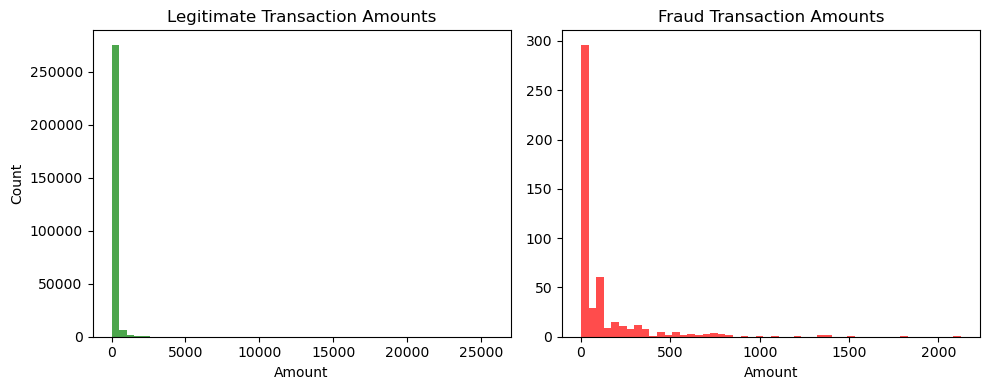

In [18]:
# Distribution of fraud vs legitimate amounts
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(legit, bins=50, color='green', alpha=0.7)
plt.title('Legitimate Transaction Amounts')
plt.xlabel('Amount')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
plt.hist(fraud, bins=50, color='red', alpha=0.7)
plt.title('Fraud Transaction Amounts')
plt.xlabel('Amount')
plt.tight_layout()
plt.show()

## Scaling Amount and splitting into train/test sets

In [21]:
# preprocessing
df = df.drop(columns=['Time']) #dropped an unnecessary column

In [22]:
df.shape #checking the columns

(284807, 30)

In [23]:
#scaling
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler() # creating a scaler object
df['Amount_Scaled'] = scaler.fit_transform(df[['Amount']])
df[['Amount','Amount_Scaled']].head()

,Amount,Amount_Scaled
0,149.62,0.244964
1,2.69,-0.342475
2,378.66,1.160686
3,123.50,0.140534
4,69.99,-0.073403


In [24]:
#dropping the column amount
df=df.drop(columns=['Amount'])

In [25]:
df.shape

(284807, 30)

In [26]:
y = df['Class']
X= df.drop(columns = ['Class'])

In [27]:
X.shape

(284807, 29)

In [28]:
y.shape

(284807,)

In [29]:
#training and test set
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size =0.20, random_state = 42) #random state is for shuffling randomly. 


In [30]:
X_train.shape

(227845, 29)

In [31]:
X_test.shape

(56962, 29)

In [32]:
y_train.shape

(227845,)

In [33]:
y_test.shape

(56962,)

## Training a baseline model to establish a benchmark

In [35]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

In [36]:
y_pred= model.predict(X_test)
print(y_pred)

[1 0 0 ... 0 0 0]


Evaluating how many frauds the model actually caught

In [38]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test,y_pred))

[[56854    10]
 [   42    56]]


a confusion matrix is a 2* 2 table
actually legit and predicted legit = 56,854 
10 legit transactions wrongly flagged as fraud - false alarm
42 fraud transactions the model missed - most dangerous mistake
56 fraud transactions correctly caught


In [40]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.57      0.68        98

    accuracy                           1.00     56962
   macro avg       0.92      0.79      0.84     56962
weighted avg       1.00      1.00      1.00     56962



## Model 2 — Logistic Regression with Class Balancing
Addressing class imbalance by telling the model to pay more attention to fraud cases.

In [41]:
model2 =LogisticRegression(class_weight ='balanced')
model2.fit(X_train,y_train)
y_pred2 =model2.predict(X_test)

In [42]:
print(y_pred2)

[1 0 0 ... 0 0 1]


In [43]:
print(confusion_matrix(y_test,y_pred2))

[[55506  1358]
 [    8    90]]


In [44]:
print(classification_report(y_test,y_pred2))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.12        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



Improving recall using a more powerful model
Logistic Regression with class_weight='balanced' improved recall to 92% but precision dropped to 6% — too many false alarms. Trying Random Forest for a better balance.

## Model 3 — Random Forest
Trying a more powerful model for better balance between precision and recall.

In [79]:
from sklearn.ensemble import RandomForestClassifier
model3 =RandomForestClassifier(class_weight='balanced')
model3.fit(X_train,y_train)
y_pred3 =model3.predict(X_test)

In [47]:
print(y_pred3)

[1 0 0 ... 0 0 0]


In [48]:
print(confusion_matrix(y_test,y_pred3))

[[56863     1]
 [   25    73]]


In [49]:
print(classification_report(y_test,y_pred3))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.99      0.74      0.85        98

    accuracy                           1.00     56962
   macro avg       0.99      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962



## Model Comparison

In [83]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression (default)', 
              'Logistic Regression (balanced)', 
              'Random Forest (balanced)'],
    'Precision': [0.88, 0.06, 0.97],
    'Recall': [0.57, 0.92, 0.74],
    'F1 Score': [0.69, 0.11, 0.84]
})
print(comparison.to_string(index=False))

                         Model  Precision  Recall  F1 Score
 Logistic Regression (default)       0.88    0.57      0.69
Logistic Regression (balanced)       0.06    0.92      0.11
      Random Forest (balanced)       0.97    0.74      0.84


## Feature Importance

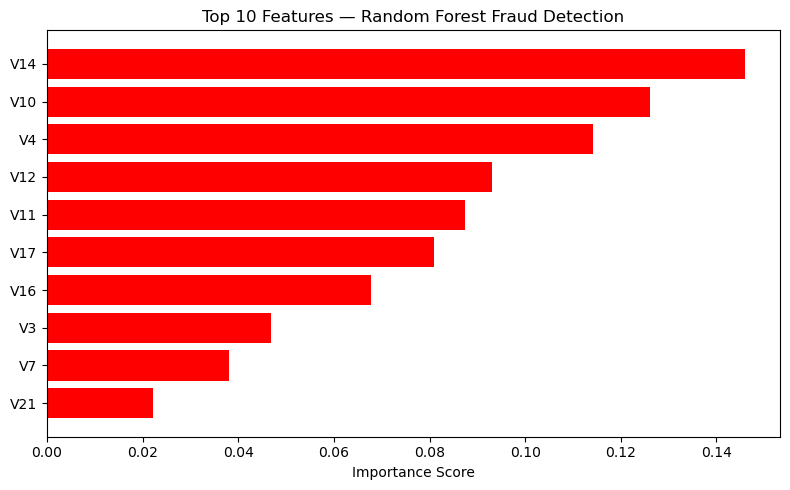

In [84]:
importances = pd.Series(model3.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
plt.barh(top_features.index[::-1], top_features.values[::-1], color='red')
plt.title('Top 10 Features — Random Forest Fraud Detection')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## Key Findings & Business Recommendations

**Fraud Patterns Found:**
- Average fraud transaction is $122 vs $88 for legitimate transactions
- Fraud has a much tighter amount distribution — suggesting card testing 
  behaviour where fraudsters make small test transactions before larger purchases
- Class imbalance is severe at 0.17% — standard accuracy is a completely 
  misleading metric for fraud detection

**Model Results:**
- Logistic Regression (default): catches 57% of fraud — misses too many
- Logistic Regression (balanced): catches 92% but 94% false alarm rate — unusable
- Random Forest (balanced): catches 74% of fraud with only 3% false alarm rate — best balance

**Business Recommendation:**
Deploy Random Forest model with a manual review queue for flagged transactions.
At 74% recall, the model catches 3 in 4 fraud attempts automatically.
The remaining 26% can be caught through manual review triggers — unusual 
location, new device, or first-time large transaction.
Cost of missing fraud far exceeds cost of reviewing false alarms.